# datasets

- https://github.com/datasets/nyse-other-listings
- https://som.yale.edu/centers/international-center-for-finance/data/historical-financial-research-data/new-york-exchange
- https://www.eoddata.com/stocklist/TSX.htm
- https://www.tsx.com/en/listings/current-market-statistics

In [139]:
import pandas as pd
import yfinance as yf
import numpy as np

FILE = r"tsx-and-amp-tsxv-listed-companies-2025-11-17-en.xlsx"

def load_tmx_list(file_path: str) -> pd.DataFrame:
    xls = pd.ExcelFile(file_path)
    dfs = []

    for sh in xls.sheet_names:
        df = pd.read_excel(file_path, sheet_name=sh, header=9)  # 👈 aquí está la clave
        df.columns = [str(c).strip() for c in df.columns]

        # columnas reales en tu archivo
        if "Root\nTicker" not in df.columns or "Exchange" not in df.columns:
            continue

        df = df.rename(columns={
            "Root\nTicker": "Symbol",
            "Name": "Company Name"
        })

        df["Exchange"] = df["Exchange"].astype(str).str.strip().str.upper()
        df["Symbol"] = df["Symbol"].astype(str).str.strip().str.upper()

        df = df[df["Symbol"].ne("") & df["Symbol"].ne("NAN")]

        # yfinance suffix
        def to_yf(sym, exch):
            if exch == "TSX":
                return sym + ".TO"
            if exch in ("TSXV", "TSX-V", "TSX VENTURE"):
                return sym + ".V"
            # fallback: si el sheet es TSXV pero el exchange viene raro
            if "TSXV" in sh.upper():
                return sym + ".V"
            return sym + ".TO"

        df["ticker_yf"] = [to_yf(s, e) for s, e in zip(df["Symbol"], df["Exchange"])]

        # columnas útiles extra (opcionales para tu clustering después)
        keep = [c for c in ["ticker_yf","Symbol","Company Name","Exchange","Sector","Market Cap (C$)\n31-October-2025"] if c in df.columns]
        df = df[keep].drop_duplicates(subset=["ticker_yf"]).reset_index(drop=True)

        dfs.append(df)

    out = pd.concat(dfs, ignore_index=True)
    return out

companies = load_tmx_list(FILE)
display(companies.head(6))
display("Total tickers:", len(companies))



def yf_exists(ticker: str) -> bool:
    try:
        h = yf.Ticker(ticker).history(period="5d")
        print(h.calendar)
        print(h.get_dividends())
        return h is not None and not h.empty
    except:
        return False

sample = companies["ticker_yf"].head(100).tolist()
ok = [t for t in sample if yf_exists(t)]
bad = [t for t in sample if t not in ok]

print("OK:", len(ok), "BAD:", len(bad))
print("Ejemplos BAD:", bad[:20])


import yfinance as yf
import pandas as pd

def yf_debug(ticker: str) -> bool:
    t = yf.Ticker(ticker)

    # 1) price existence
    h = t.history(period="5d")
    ok_price = h is not None and not h.empty

    # 2) dividends existence
    try:
        div = t.dividends  # Series
    except Exception:
        div = pd.Series(dtype=float)

    print("\n---", ticker, "---")
    print("Has price data?", ok_price, "| last close:", (h["Close"].iloc[-1] if ok_price else None))
    print("Dividends rows:", (len(div) if div is not None else 0))
    if div is not None and not div.empty:
        print("Last 10 dividends:\n", div.tail(10))
    else:
        print("No dividends returned (empty).")

    # calendar (a veces viene vacío, es normal)
    try:
        cal = t.calendar
        print("Calendar:\n", cal if cal is not None else "None")
    except Exception:
        print("Calendar: error/empty")

    return ok_price


sample = companies["ticker_yf"].head(10).tolist()

for tk in sample:
    yf_debug(tk)
    
    

from pathlib import Path
import pandas as pd
from datetime import datetime, timedelta

CACHE_DIR = Path("cache_yf")
CACHE_DIR.mkdir(exist_ok=True)

STALE_DAYS = 7   # si el archivo tiene más de 7 días, se refresca

def cache_path(name: str) -> Path:
    return CACHE_DIR / f"{name}.csv"

def is_cache_fresh(fp: Path, stale_days: int = STALE_DAYS) -> bool:
    if not fp.exists():
        return False
    mtime = datetime.fromtimestamp(fp.stat().st_mtime)
    return (datetime.now() - mtime) <= timedelta(days=stale_days)

def basic_validate(df: pd.DataFrame, required_cols: list[str], min_rows: int = 100) -> None:
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Cache inválido: faltan columnas {missing}")
    if len(df) < min_rows:
        raise ValueError(f"Cache inválido: pocas filas ({len(df)} < {min_rows})")



from pathlib import Path
import pandas as pd
from datetime import datetime, timedelta

CACHE_DIR = Path("cache_yf")
CACHE_DIR.mkdir(exist_ok=True)

def _fp(name: str) -> Path:
    return CACHE_DIR / f"{name}.csv"

def _is_fresh(fp: Path, stale_days: int) -> bool:
    if not fp.exists():
        return False
    mtime = datetime.fromtimestamp(fp.stat().st_mtime)
    return (datetime.now() - mtime) <= timedelta(days=stale_days)

def _validate_features(df: pd.DataFrame) -> None:
    required = [
        "ticker_yf", "last_close", "max_drawdown",
        "EMA_20", "EMA_52", "EMA_200", "MACD", "MACD_signal", "RSI_14"
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Cache features inválido. Faltan columnas: {missing}")
    if df["ticker_yf"].isna().all():
        raise ValueError("Cache features inválido. ticker_yf vacío.")
    if df.dropna(subset=["last_close"]).shape[0] < 20:
        raise ValueError("Cache features inválido. Muy pocos tickers con last_close.")

def _validate_div_events(df: pd.DataFrame) -> None:
    # Como no sé tus columnas exactas, valido mínimo que no esté vacío y que haya ticker.
    if df is None or not isinstance(df, pd.DataFrame):
        raise ValueError("Cache div_events inválido: no es DataFrame.")
    if df.empty:
        raise ValueError("Cache div_events inválido: vacío.")
    if "ticker_yf" not in df.columns and "ticker" not in df.columns:
        raise ValueError("Cache div_events inválido: no tiene ticker_yf/ticker.")


,ticker_yf,Symbol,Company Name,Exchange,Sector,Market Cap (C$)\n31-October-2025
0,IGBT.TO,IGBT,2028 Investment Grade Bond Trust,TSX,Closed-End Funds,3.978969e+07
1,BTCQ.TO,BTCQ,3iQ Bitcoin ETF,TSX,ETP,2.611489e+08
2,ETHQ.TO,ETHQ,3iQ Ether Staking ETF,TSX,ETP,9.630603e+07
3,SOLQ.TO,SOLQ,3iQ Solana Staking ETF,TSX,ETP,2.530920e+08
4,XRPQ.TO,XRPQ,3iQ XRP ETF,TSX,ETP,1.141848e+08
5,VNP.TO,VNP,5N Plus Inc.,TSX,Clean Technology & Renewable Energy,1.786825e+09


'Total tickers:'

3562

$IGBT.TO: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$AGF.TO: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$AKT.TO: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$AD.TO: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$AP.TO: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$HOT.TO: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$AND.TO: possibly delisted; no price data found  (period=5d)
$ADW.TO: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$AX.TO: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$ACO.

OK: 0 BAD: 100
Ejemplos BAD: ['IGBT.TO', 'BTCQ.TO', 'ETHQ.TO', 'SOLQ.TO', 'XRPQ.TO', 'VNP.TO', 'AW.TO', 'AAB.TO', 'ABRA.TO', 'FAP.TO', 'ADN.TO', 'HDGE.TO', 'ARB.TO', 'ATSX.TO', 'INCM.TO', 'ONEC.TO', 'ACD.TO', 'ARA.TO', 'ACX.TO', 'ADCO.TO']


...

Calendar:
 {}

--- SOLQ.TO ---
Has price data? True | last close: 13.720000267028809
Dividends rows: 0
No dividends returned (empty).


HTTP Error 404: 


Calendar:
 {}

--- XRPQ.TO ---
Has price data? True | last close: 11.800000190734863
Dividends rows: 0
No dividends returned (empty).


HTTP Error 404: 


Calendar:
 {}

--- VNP.TO ---
Has price data? True | last close: 18.110000610351562
Dividends rows: 0
No dividends returned (empty).
Calendar:
 {'Earnings Date': [datetime.date(2025, 11, 3)], 'Earnings High': 0.09, 'Earnings Low': 0.09, 'Earnings Average': 0.09, 'Revenue High': 100400000, 'Revenue Low': 85000000, 'Revenue Average': 92300000}

--- AW.TO ---
Has price data? True | last close: 37.130001068115234
Dividends rows: 4
Last 10 dividends:
 Date
2024-12-13 00:00:00-05:00    0.375
2025-03-14 00:00:00-04:00    0.480
2025-06-13 00:00:00-04:00    0.480
2025-09-15 00:00:00-04:00    0.480
Name: Dividends, dtype: float64
Calendar:
 {'Dividend Date': datetime.date(2025, 12, 23), 'Ex-Dividend Date': datetime.date(2025, 12, 14), 'Earnings Date': [], 'Earnings High': 0.66, 'Earnings Low': 0.60767, 'Earnings Average': 0.63384, 'Revenue High': 88427900, 'Revenue Low': 86700000, 'Revenue Average': 87563950}

--- AAB.TO ---
Has price data? True | last close: 0.029999999329447746
Dividends rows:

In [140]:
import numpy as np
import pandas as pd

def make_weekly_dataset(df_daily_ta: pd.DataFrame) -> pd.DataFrame:
    # Ensure date is index
    df = df_daily_ta.copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.set_index("Date")

    # Resample to weekly (Friday close)
    weekly = df.resample("W-FRI").agg({
        "Open": "first",
        "High": "max",
        "Low": "min",
        "Close": "last",
        "MACD": "last",
        "MACD_signal": "last",
        "RSI_14": "last",
        # "Volume": "sum",   # if available
    })

    # Weekly % return
    weekly["Weekly_return"] = weekly["Close"].pct_change()

    # Target: did next week go UP?
    weekly["Target"] = (weekly["Close"].shift(-1) > weekly["Close"]).astype(int)

    # Pandemic indicator
    weekly["Pandemic"] = weekly.index.to_series().between(
        "2019-12-01", "2021-12-31"
    ).astype(int)

    # -----------------------------
    #  ⭐ ADD WEEK IDENTIFIERS ⭐
    # -----------------------------

    # Year for each week
    weekly["Year"] = weekly.index.year

    # ISO week number (1–52)
    weekly["Week_Number"] = weekly.index.isocalendar().week.astype(int)

    # Unique identifier (Ex: "2023-47")
    weekly["Week_ID"] = (
        weekly["Year"].astype(str) + "-" + weekly["Week_Number"].astype(str).str.zfill(2)
    )

    # Remove rows with NaN
    weekly = weekly.dropna()

    return weekly



import yfinance as yf

# Fetch stock data from Yahoo Finance

def get_stock_price(ticker,history=5):
    # time.sleep(4) #To avoid rate limit error
    ticker = ticker.upper().strip()
    stock = yf.Ticker(ticker)
    df = stock.history(period="1y")
    df=df[["Close","Volume"]]
    df.index=[str(x).split()[0] for x in list(df.index)]
    df.index.rename("Date",inplace=True)
    df=df[-history:]
    # print(df.columns)
    
    return df.to_string()

# Fetch financial statements from Yahoo Finance
def get_financial_statements(ticker):
    # time.sleep(4) #To avoid rate limit error
    ticker = ticker.upper().strip()    
    company = yf.Ticker(ticker)
    balance_sheet = company.balance_sheet
    if balance_sheet.shape[1]>=3:
        balance_sheet=balance_sheet.iloc[:,:3]    # Remove 4th years data
    balance_sheet=balance_sheet.dropna(how="any")
    balance_sheet = balance_sheet.to_string()
    
    # cash_flow = company.cash_flow.to_string()
    # print(balance_sheet)
    # print(cash_flow)
    return balance_sheet



def analyze_week(df_weekly: pd.DataFrame, analysis_week_end=None, years_back=20):
    """
    Professional weekly analysis:
    - Gets current week index
    - Filters last N years
    - Selects only same Week_Number for seasonal analysis
    - Returns structured report + probability of next-week increase
    """

    # 1. Determine the week to analyze
    if analysis_week_end is None:
        analysis_week_end = df_weekly.index.max().date()

    analysis_week_end = pd.to_datetime(analysis_week_end)

    # Current Friday (week index)
    week_idx = df_weekly.index[df_weekly.index <= analysis_week_end].max()
    current = df_weekly.loc[week_idx]

    # Week number
    week_num = int(current["Week_Number"])

    # 2. Historical window
    window_start = week_idx - pd.DateOffset(years=years_back)
    hist_window = df_weekly.loc[window_start:week_idx]

    # 3. Filter identical week numbers
    hist = hist_window[hist_window["Week_Number"] == week_num].copy()
    # print(hist)
    # 4. Compute statistics
    mean_ret = hist["Weekly_return"].mean()
    std_ret = hist["Weekly_return"].std()
    min_ret = hist["Weekly_return"].min()
    max_ret = hist["Weekly_return"].max()

    # 5. Percentile of current week
    current_ret = current["Weekly_return"]
    percentile = (hist["Weekly_return"] <= current_ret).mean()

    # 🔥 6. Probability that NEXT WEEK goes UP (Target = 1)
    prob_up = hist["Target"].mean()

    # 7. Build professional report dictionary
    report = {
        "week_index": week_idx,
        "week_number": week_num,
        "years_back": years_back,
        "current_week": {
            "close": float(current["Close"]),
            "weekly_return": float(current["Weekly_return"]),
            "MACD": float(current["MACD"]),
            "MACD_signal": float(current["MACD_signal"]),
            "RSI_14": float(current["RSI_14"]),
            "Pandemic": int(current["Pandemic"])
        },
        "historical_stats": {
            "num_samples": int(len(hist)),
            "mean_weekly_return": float(mean_ret),
            "std_weekly_return": float(std_ret),
            "min_weekly_return": float(min_ret),
            "max_weekly_return": float(max_ret),
            "percentile_of_current_return": float(percentile)
        },
        "forecast": {
            "probability_next_week_up": float(prob_up),
            "probability_next_week_down": float(1 - prob_up)
        },
        "historical_dataframe": hist
    }

    return report,hist


# ---------- helpers ----------
def max_drawdown(close: pd.Series) -> float:
    """Max drawdown en % (negativo)."""
    close = close.dropna()
    if close.empty:
        return np.nan
    peak = close.cummax()
    dd = close / peak - 1.0
    return float(dd.min())  # ej: -0.42 => -42%




def safe_history(ticker: str, period="1y") -> pd.DataFrame:
    """Fallback individual para cuando yf.download no trae el ticker."""
    try:
        t = yf.Ticker(ticker)
        df = t.history(period=period, auto_adjust=False)
        if df is None or df.empty:
            return pd.DataFrame()
        return df
    except Exception:
        return pd.DataFrame()


def rsi(series: pd.Series, period: int = 14) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def add_ta(close: pd.Series) -> pd.DataFrame:
    out = pd.DataFrame({"Close": close})
    out["EMA_20"]  = close.ewm(span=20, adjust=False).mean()
    out["EMA_52"]  = close.ewm(span=52, adjust=False).mean()
    out["EMA_200"] = close.ewm(span=200, adjust=False).mean()
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    out["MACD"] = ema12 - ema26
    out["MACD_signal"] = out["MACD"].ewm(span=9, adjust=False).mean()
    out["RSI_14"] = rsi(close, 14)
    return out

def infer_dividend_frequency(n_pay: int) -> str:
    if n_pay >= 11: return "Monthly"
    if n_pay == 4:  return "Quarterly"
    if n_pay == 2:  return "Semi-Annual"
    if n_pay == 1:  return "Annual"
    if n_pay == 0:  return "No dividends"
    return "Irregular"



import numpy as np
import pandas as pd
import yfinance as yf

def dividends_series_robust(ticker: str, period="5y") -> pd.Series:
    # 1) Ticker().dividends
    try:
        div = yf.Ticker(ticker).dividends
        # si por alguna razón viene DataFrame, lo convertimos
        if isinstance(div, pd.DataFrame):
            # busca una columna razonable
            for c in ["Dividends", "dividends", "Dividend", "amount"]:
                if c in div.columns:
                    div = div[c]
                    break

        if isinstance(div, pd.Series) and not div.empty:
            div = div.sort_index()
            div.index = pd.to_datetime(div.index).tz_localize(None)
            div = pd.to_numeric(div, errors="coerce").dropna()
            div = div[div != 0]
            return div
    except Exception:
        pass

    # 2) download(actions=True) fallback
    try:
        df = yf.download(
            ticker, period=period, actions=True,
            auto_adjust=False, progress=False, threads=False
        )
        if df is not None and not df.empty and "Dividends" in df.columns:
            div2 = df["Dividends"].dropna()
            div2 = div2[div2 != 0]
            div2.index = pd.to_datetime(div2.index).tz_localize(None)
            div2 = pd.to_numeric(div2, errors="coerce").dropna()
            return div2.sort_index()
    except Exception:
        pass

    return pd.Series(dtype=float)

def dividends_events_df(tickers, period="5y") -> pd.DataFrame:
    rows = []
    for tk in tickers:
        div = dividends_series_robust(tk, period=period)

        # div YA debe ser Series, pero por seguridad:
        if not isinstance(div, pd.Series) or div.empty:
            continue

        tmp = pd.DataFrame({
            "ticker_yf": tk,
            "div_date": pd.to_datetime(div.index),
            "div_amount": pd.to_numeric(div.values, errors="coerce")
        }).dropna(subset=["div_date", "div_amount"])

        rows.append(tmp)

    if not rows:
        return pd.DataFrame(columns=["ticker_yf","div_date","div_amount"])

    ev = pd.concat(rows, ignore_index=True)
    ev = ev.sort_values(["ticker_yf","div_date"]).reset_index(drop=True)
    return ev


def dividends_summary_df(div_events: pd.DataFrame, last_close: pd.Series) -> pd.DataFrame:
    """
    div_events: columns [ticker_yf, div_date, div_amount]
    last_close: Series indexed by ticker_yf with last_close price
    """
    if div_events.empty:
        return pd.DataFrame(columns=[
            "ticker_yf","dividend_ttm","payments_ttm","div_freq","last_div_date","div_yield_ttm"
        ])

    cutoff = pd.Timestamp.today() - pd.Timedelta(days=365)
    ttm = div_events[div_events["div_date"] >= cutoff].copy()

    g = ttm.groupby("ticker_yf")["div_amount"]
    out = pd.DataFrame({
        "dividend_ttm": g.sum(),
        "payments_ttm": g.size()
    }).reset_index()

    out["div_freq"] = out["payments_ttm"].apply(infer_dividend_frequency)

    # last dividend date (all-time)
    last_dates = div_events.groupby("ticker_yf")["div_date"].max().rename("last_div_date").reset_index()
    out = out.merge(last_dates, on="ticker_yf", how="left")

    # yield
    px = last_close.rename("last_close").reset_index()
    px.columns = ["ticker_yf","last_close"]
    out = out.merge(px, on="ticker_yf", how="left")
    out["div_yield_ttm"] = np.where(
        out["last_close"] > 0,
        out["dividend_ttm"] / out["last_close"],
        np.nan
    )

    # optional: clean
    out = out.drop(columns=["last_close"])
    return out


def earnings_next_df(tickers) -> pd.DataFrame:
    rows = []
    for tk in tickers:
        t = yf.Ticker(tk)
        nxt = pd.NaT
        eps_est = np.nan
        rep_eps = np.nan
        surprise = np.nan

        try:
            ed = t.earnings_dates
            if ed is not None and not ed.empty:
                ed = ed.copy()
                ed.index = pd.to_datetime(ed.index).tz_localize(None, ambiguous="NaT", nonexistent="NaT")
                future = ed[ed.index >= pd.Timestamp.today()]
                row = (future.iloc[0] if not future.empty else ed.iloc[-1])
                nxt = (future.index[0] if not future.empty else pd.NaT)
                eps_est = float(row.get("EPS Estimate", np.nan))
                rep_eps = float(row.get("Reported EPS", np.nan))
                surprise = float(row.get("Surprise(%)", np.nan))
        except Exception:
            pass

        rows.append({
            "ticker_yf": tk,
            "next_earnings_date": nxt,
            "eps_estimate": eps_est,
            "reported_eps": rep_eps,
            "surprise_pct": surprise
        })

    return pd.DataFrame(rows)

def build_features_robust(companies: pd.DataFrame, period="1y", limit=None, fallback=True, include_earnings=True):
    tickers = companies["ticker_yf"].dropna().unique().tolist()
    if limit:
        tickers = tickers[:limit]

    px = yf.download(tickers, period=period, auto_adjust=False, progress=False, group_by="ticker", threads=True)

    def get_df_from_batch(ticker: str) -> pd.DataFrame:
        if px is None or px.empty:
            return pd.DataFrame()
        if isinstance(px.columns, pd.MultiIndex):
            if ticker in px.columns.get_level_values(0):
                return px[ticker].dropna(how="all")
            return pd.DataFrame()
        return px.dropna(how="all")

    price_rows = []
    used_fallback = 0

    for t in tickers:
        df_t = get_df_from_batch(t)

        if df_t.empty and fallback:
            df_t = safe_history(t, period=period)
            if not df_t.empty:
                used_fallback += 1

        if df_t.empty or "Close" not in df_t.columns:
            continue

        close = df_t["Close"].dropna()
        if close.empty:
            continue

        ta = add_ta(close)
        last = ta.iloc[-1]
        last_price = float(last["Close"])
        dd = max_drawdown(ta["Close"])

        price_rows.append({
            "ticker_yf": t,
            "last_close": last_price,
            "max_drawdown": dd,
            "EMA_20": float(last["EMA_20"]),
            "EMA_52": float(last["EMA_52"]),
            "EMA_200": float(last["EMA_200"]),
            "MACD": float(last["MACD"]),
            "MACD_signal": float(last["MACD_signal"]),
            "RSI_14": float(last["RSI_14"]),
        })

    price_feat = pd.DataFrame(price_rows)
    out = companies.merge(price_feat, on="ticker_yf", how="left")

    # ---- dividends (separado, robusto) ----
    last_close_by = price_feat.set_index("ticker_yf")["last_close"]
    div_events = dividends_events_df(price_feat["ticker_yf"].tolist(), period="5y")
    div_sum = dividends_summary_df(div_events, last_close_by)
    out = out.merge(div_sum, on="ticker_yf", how="left")

    # ---- earnings (opcional) ----
    if include_earnings:
        earn = earnings_next_df(price_feat["ticker_yf"].tolist())
        out = out.merge(earn, on="ticker_yf", how="left")

    print(f"Tickers input: {len(tickers)} | Price ok: {len(price_feat)} | Fallback used: {used_fallback} | Div events rows: {len(div_events)}")
    return out, div_events

def build_features_cached(
    companies: pd.DataFrame,
    cache_key: str,
    period="1y",
    stale_days=7,
    limit=None,
    fallback=True,
    include_earnings=True,
    force_refresh=False
):
    fp_feat = _fp(f"{cache_key}_features")
    fp_div  = _fp(f"{cache_key}_div_events")

    # 1) Intentar cargar cache si está fresco
    if not force_refresh and _is_fresh(fp_feat, stale_days) and _is_fresh(fp_div, stale_days):
        feat = pd.read_csv(fp_feat)
        div  = pd.read_csv(fp_div)

        _validate_features(feat)
        _validate_div_events(div)

        print(f"✅ Cache usado: {fp_feat.name} + {fp_div.name}")
        return feat, div

    # 2) Si no, recalcular
    print(f"⬇️ Recalculando (sin cache o stale): {cache_key}")
    feat, div = build_features_robust(
        companies=companies,
        period=period,
        limit=limit,
        fallback=fallback,
        include_earnings=include_earnings
    )

    # 3) Validar antes de guardar
    _validate_features(feat)
    _validate_div_events(div)

    # 4) Guardar
    feat.to_csv(fp_feat, index=False)
    div.to_csv(fp_div, index=False)
    print(f"💾 Cache guardado: {fp_feat.name} + {fp_div.name}")

    return feat, div


In [141]:
df_features, df_div_events = build_features_cached(companies=companies,
                                                   cache_key="tsx",
                                                   period="1y", 
                                                   limit=300, 
                                                   fallback=True)

✅ Cache usado: tsx_features.csv + tsx_div_events.csv


Dataset Shape: (3562, 23)


,Name,dtypes,Missing,percentage missing,Uniques,First Value,Second Value,Third Value,Entropy
0,ticker_yf,object,0,0.000000,3562,IGBT.TO,BTCQ.TO,ETHQ.TO,11.80
1,Symbol,object,0,0.000000,3562,IGBT,BTCQ,ETHQ,11.80
2,Company Name,object,0,0.000000,3562,2028 Investment Grade Bond Trust,3iQ Bitcoin ETF,3iQ Ether Staking ETF,11.80
3,Exchange,object,0,0.000000,2,TSX,TSX,TSX,0.99
4,Sector,object,0,0.000000,15,Closed-End Funds,ETP,ETP,2.74
5,Market Cap (C$)\n31-October-2025,float64,0,0.000000,3548,39789686.4,261148949.9,96306025.53,11.79
6,last_close,float64,3277,91.998877,275,NaN,18.51,15.8,8.08
7,max_drawdown,float64,3277,91.998877,285,NaN,-0.322474,-0.639279,8.15
8,EMA_20,float64,3277,91.998877,285,NaN,20.055939,17.107646,8.15
9,EMA_52,float64,3277,91.998877,285,NaN,21.579921,18.550743,8.15


Sample usado para plots: 3562 filas, 23 columnas


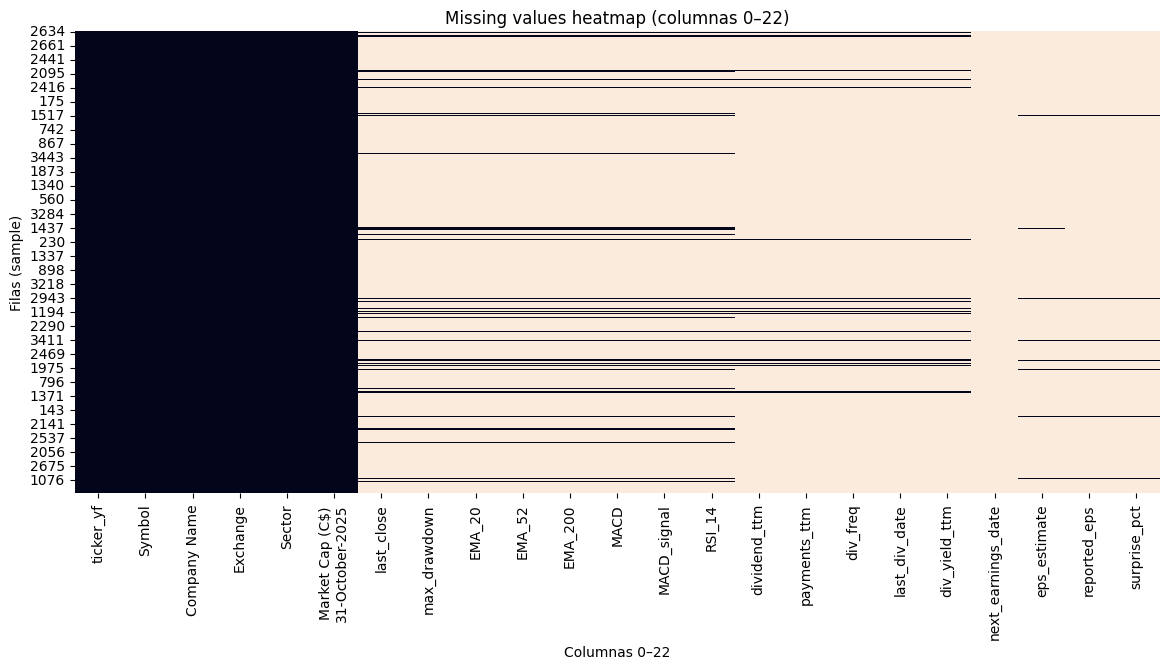

In [142]:
#eda

import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats
import glob

def plot_missing_by_batches(df, sample_size=5000, cols_per_plot=40, random_state=42):
    """
    Hace heatmaps de NA usando:
    - una muestra de filas (sample_size)
    - columnas en batches de tamaño cols_per_plot
    """
    # 1) sample de filas (igual idea que antes)
    n_rows = len(df)
    sample_size = min(sample_size, n_rows)
    sample = df.sample(sample_size, random_state=random_state)

    n_cols = sample.shape[1]
    col_names = sample.columns.tolist()

    print(f"Sample usado para plots: {sample_size} filas, {n_cols} columnas")

    # 2) recorrer columnas en bloques
    for start in range(0, n_cols, cols_per_plot):
        end = min(start + cols_per_plot, n_cols)
        batch_cols = col_names[start:end]

        plt.figure(figsize=(14, 6))
        sns.heatmap(sample[batch_cols].isnull(), cbar=False)
        plt.title(f"Missing values heatmap (columnas {start}–{end-1})")
        plt.xlabel(f"Columnas {start}–{end-1}")
        plt.ylabel("Filas (sample)")
        plt.show()


def resumetable(df):
    print(f"Dataset Shape: {df.shape}")
    summary = pd.DataFrame(df.dtypes,columns=['dtypes'])
    summary = summary.reset_index()
    summary['Name'] = summary['index']
    summary = summary[['Name','dtypes']]
    summary['Missing'] = df.isnull().sum().values  
    summary['percentage missing'] = df.isnull().sum().values/df.shape[0] * 100    
    summary['Uniques'] = df.nunique().values
    summary['First Value'] = df.loc[0].values
    summary['Second Value'] = df.loc[1].values
    summary['Third Value'] = df.loc[2].values

    for name in summary['Name'].value_counts().index:
        summary.loc[summary['Name'] == name, 'Entropy'] = round(stats.entropy(df[name].value_counts(normalize=True), base=2),2) 

    return summary


display(resumetable(df_features))
plot_missing_by_batches(df_features, sample_size=5000, cols_per_plot=40)

In [143]:
pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.expand_frame_repr", False)

display(df_features.shape)
display(df_features.sort_values("dividend_ttm", ascending=False).head(100))

(3562, 23)

,ticker_yf,Symbol,Company Name,Exchange,Sector,Market Cap (C$)\n31-October-2025,last_close,max_drawdown,EMA_20,EMA_52,EMA_200,MACD,MACD_signal,RSI_14,dividend_ttm,payments_ttm,div_freq,last_div_date,div_yield_ttm,next_earnings_date,eps_estimate,reported_eps,surprise_pct
90,BMO.TO,BMO,Bank of Montreal,TSX,Financial Services,1.245534e+11,181.910004,-0.165695,177.107438,174.993884,162.022019,1.617868,0.819929,67.136817,6.440,4.0,Quarterly,2025-10-30,0.035402,NaN,3.07,3.04,-0.98
91,BNS.TO,BNS,Bank of Nova Scotia (The),TSX,Financial Services,1.138837e+11,100.550003,-0.189996,97.824172,94.120663,84.377451,1.970128,1.826769,78.884898,4.320,4.0,Quarterly,2025-10-07,0.042964,NaN,2.00,2.06,3.14
97,BCE.TO,BCE,BCE Inc.,TSX,Comm. & Media,3.256919e+10,32.500000,-0.194773,32.440830,32.559565,32.624586,-0.043068,-0.044211,50.583634,2.872,4.0,Quarterly,2025-09-15,0.088369,NaN,0.77,0.85,10.09
180,ZEO.TO,ZEO,BMO Equal Weight Oil & Gas Index ETF,TSX,ETP,2.177377e+08,80.970001,-0.176228,81.688893,80.534571,77.044221,0.372778,0.674904,39.715201,2.710,4.0,Quarterly,2025-09-29,0.033469,NaN,NaN,NaN,NaN
167,ZWEN.TO,ZWEN,BMO Covered Call Energy ETF,TSX,ETP,1.185179e+08,28.080000,-0.201168,28.508968,28.396556,28.108294,-0.030118,0.054694,39.387749,2.640,12.0,Monthly,2025-11-26,0.094017,NaN,NaN,NaN,NaN
170,ZWT.TO,ZWT,BMO Covered Call Technology ETF,TSX,ETP,1.971875e+08,58.560001,-0.271177,60.388915,59.927719,56.170670,-0.113801,0.076936,30.204056,2.550,12.0,Monthly,2025-11-26,0.043545,NaN,NaN,NaN,NaN
248,ZPAY.TO,ZPAY,BMO Premium Yield ETF,TSX,ETP,4.450735e+08,32.520000,-0.135239,32.676757,32.670724,32.350427,-0.091335,-0.050253,23.828172,2.320,12.0,Monthly,2025-11-26,0.071341,NaN,NaN,NaN,NaN
29,AEM.TO,AEM,Agnico Eagle Mines Limited,TSX,Mining,1.133419e+11,231.759995,-0.167319,233.322666,228.965627,194.086204,-0.051809,0.831603,47.927247,2.239,4.0,Quarterly,2025-12-01,0.009661,NaN,0.41,0.41,-0.70
197,ZWG.TO,ZWG,BMO Global High Dividend Covered Call ETF,TSX,ETP,2.793000e+08,33.759998,-0.157079,33.528388,33.218649,32.445990,0.122262,0.124200,50.000000,2.100,12.0,Monthly,2025-11-26,0.062204,NaN,NaN,NaN,NaN
14,INCM.TO,INCM,Accelerate Diversified Credit Income Fund,TSX,ETP,6.929750e+07,15.340000,-0.282863,15.533877,15.627430,16.768723,0.010692,0.034966,32.743406,1.960,12.0,Monthly,2025-11-28,0.127771,NaN,NaN,NaN,NaN


In [144]:
# 1) mira cuántos NaN o ceros tienes
print("NaN dividend_ttm:", df_features["dividend_ttm"].isna().mean())
print("0 dividend_ttm:", (df_features["dividend_ttm"].fillna(0) == 0).mean())
print("NaN div_yield_ttm:", df_features["div_yield_ttm"].isna().mean())

NaN dividend_ttm: 0.950870297585626
0 dividend_ttm: 0.950870297585626
NaN div_yield_ttm: 0.950870297585626


In [145]:
display(df_features.shape)


high_div = df_features[df_features["div_yield_ttm"].fillna(0) >= 0.04].copy()
high_div = high_div.sort_values("div_yield_ttm", ascending=False)

display(high_div.shape)
display(high_div[["ticker_yf","Company Name","Exchange","div_yield_ttm","dividend_ttm","payments_ttm","div_freq","last_close"]].head(50))
print("Total >=#%:", len(high_div))


(3562, 23)

(46, 23)

,ticker_yf,Company Name,Exchange,div_yield_ttm,dividend_ttm,payments_ttm,div_freq,last_close
14,INCM.TO,Accelerate Diversified Credit Income Fund,TSX,0.127771,1.960,12.0,Monthly,15.340000
292,ZPH.TO,BMO US Put Write Hedged to CAD ETF,TSX,0.100348,1.440,12.0,Monthly,14.350000
278,ZXCO.TO,BMO Target 2027 Canadian Corporate Bond ETF,TSX,0.098117,0.990,2.0,Semi-Annual,10.090000
291,ZPW.TO,BMO US Put Write ETF,TSX,0.094997,1.500,12.0,Monthly,15.790000
167,ZWEN.TO,BMO Covered Call Energy ETF,TSX,0.094017,2.640,12.0,Monthly,28.080000
136,PRM.TO,Big Pharma Split Corp.,TSX,0.091556,1.236,12.0,Monthly,13.500000
97,BCE.TO,BCE Inc.,TSX,0.088369,2.872,4.0,Quarterly,32.500000
135,BNK.TO,Big Banc Split Corp.,TSX,0.084706,1.440,12.0,Monthly,17.000000
76,AI.TO,Atrium Mortgage Investments Corporation,TSX,0.081109,0.936,12.0,Monthly,11.540000
172,ZWU.TO,BMO Covered Call Utilities ETF,TSX,0.076225,0.840,12.0,Monthly,11.020000


Total >=#%: 46


In [146]:
df_features[df_features["ticker_yf"] == "BCE.TO"]

,ticker_yf,Symbol,Company Name,Exchange,Sector,Market Cap (C$)\n31-October-2025,last_close,max_drawdown,EMA_20,EMA_52,EMA_200,MACD,MACD_signal,RSI_14,dividend_ttm,payments_ttm,div_freq,last_div_date,div_yield_ttm,next_earnings_date,eps_estimate,reported_eps,surprise_pct
97,BCE.TO,BCE,BCE Inc.,TSX,Comm. & Media,3.256919e+10,32.5,-0.194773,32.44083,32.559565,32.624586,-0.043068,-0.044211,50.583634,2.872,4.0,Quarterly,2025-09-15,0.088369,NaN,0.77,0.85,10.09


In [147]:

df_features[df_features["ticker_yf"] == "FAP.TO"]

,ticker_yf,Symbol,Company Name,Exchange,Sector,Market Cap (C$)\n31-October-2025,last_close,max_drawdown,EMA_20,EMA_52,EMA_200,MACD,MACD_signal,RSI_14,dividend_ttm,payments_ttm,div_freq,last_div_date,div_yield_ttm,next_earnings_date,eps_estimate,reported_eps,surprise_pct
9,FAP.TO,FAP,abrdn Asia-Pacific Income Fund VCC,TSX,Closed-End Funds,96223350.53,2.87,-0.074074,2.880646,2.89592,2.895139,-0.007799,-0.010111,46.153825,0.18,10.0,Irregular,2025-11-21,0.062718,NaN,NaN,NaN,NaN


In [148]:
df_features.head(10)

,ticker_yf,Symbol,Company Name,Exchange,Sector,Market Cap (C$)\n31-October-2025,last_close,max_drawdown,EMA_20,EMA_52,EMA_200,MACD,MACD_signal,RSI_14,dividend_ttm,payments_ttm,div_freq,last_div_date,div_yield_ttm,next_earnings_date,eps_estimate,reported_eps,surprise_pct
0,IGBT.TO,IGBT,2028 Investment Grade Bond Trust,TSX,Closed-End Funds,3.978969e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BTCQ.TO,BTCQ,3iQ Bitcoin ETF,TSX,ETP,2.611489e+08,18.510000,-0.322474,20.055939,21.579921,22.855240,-0.719835,-0.803956,44.858618,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ETHQ.TO,ETHQ,3iQ Ether Staking ETF,TSX,ETP,9.630603e+07,15.800000,-0.639279,17.107646,18.550743,18.725194,-0.532409,-0.707651,47.921225,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,SOLQ.TO,SOLQ,3iQ Solana Staking ETF,TSX,ETP,2.530920e+08,13.720000,-0.494659,15.431658,17.482115,18.106807,-0.948424,-1.049114,39.184176,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,XRPQ.TO,XRPQ,3iQ XRP ETF,TSX,ETP,1.141848e+08,11.800000,-0.467269,13.358720,14.671700,15.417206,-0.680744,-0.625762,30.292594,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,VNP.TO,VNP,5N Plus Inc.,TSX,Clean Technology & Renewable Energy,1.786825e+09,18.110001,-0.437079,19.262913,18.649450,13.963183,-0.150015,0.044447,42.882893,NaN,NaN,NaN,NaN,NaN,NaN,0.02,0.02,14.29
6,AW.TO,AW,A & W Food Services of Canada Inc.,TSX,Consumer Products & Services,8.771189e+08,37.130001,-0.194631,37.482157,37.441619,36.800872,0.099731,0.111752,44.562337,1.44,3.0,Irregular,2025-09-15,0.038783,NaN,NaN,NaN,NaN
7,AAB.TO,AAB,Aberdeen International Inc.,TSX,Financial Services,4.805618e+06,0.025000,-0.375000,0.029823,0.031248,0.033931,-0.000883,-0.000704,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,ABRA.TO,ABRA,AbraSilver Resource Corp.,TSX,Mining,1.047174e+09,10.220000,-0.288136,9.275172,8.015274,5.842046,0.884886,0.819199,69.033528,NaN,NaN,NaN,NaN,NaN,NaN,-0.05,-0.10,-100.00
9,FAP.TO,FAP,abrdn Asia-Pacific Income Fund VCC,TSX,Closed-End Funds,9.622335e+07,2.870000,-0.074074,2.880646,2.895920,2.895139,-0.007799,-0.010111,46.153825,0.18,10.0,Irregular,2025-11-21,0.062718,NaN,NaN,NaN,NaN


In [149]:
features_for_kmeans = [
    "last_close",
    "dividend_ttm",
    "div_yield_ttm",
    "payments_ttm",
    "max_drawdown",
    "EMA_20",
    "EMA_52",
    "EMA_200",
    "RSI_14"
]


X = df_features[features_for_kmeans].copy()
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

# dividendos explícitamente a 0
for c in ["dividend_ttm", "div_yield_ttm", "payments_ttm"]:
    if c in X_imputed.columns:
        X_imputed[c] = X[c].fillna(0)
        

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=20
)

clusters = kmeans.fit_predict(X_scaled)

df_features["cluster"] = clusters

pd.crosstab(
    df_features["cluster"],
    df_features["Sector"],
    normalize="index"
).round(2)


Sector,CPC,Clean Technology & Renewable Energy,Closed-End Funds,Comm. & Media,Consumer Products & Services,ETP,Financial Services,Industrial Products & Services,Life Sciences,Mining,Oil & Gas,Real Estate,SPAC,Technology,Utilities & Pipelines
cluster,,,,,,,,,,,,,,,
0,0.05,0.02,0.02,0.01,0.03,0.34,0.03,0.04,0.03,0.31,0.04,0.03,0.0,0.05,0.01
1,0.00,0.00,0.00,0.00,0.00,0.60,0.20,0.00,0.00,0.20,0.00,0.00,0.0,0.00,0.00
2,0.00,0.05,0.00,0.01,0.07,0.32,0.03,0.08,0.09,0.22,0.05,0.00,0.0,0.07,0.00
3,0.00,0.00,0.00,0.00,0.04,0.84,0.02,0.05,0.00,0.04,0.00,0.00,0.0,0.02,0.00
4,0.00,0.01,0.04,0.01,0.01,0.86,0.01,0.04,0.00,0.00,0.00,0.00,0.0,0.00,0.01


In [150]:
df_features.groupby("cluster")[features_for_kmeans].median().round(3)

,last_close,dividend_ttm,div_yield_ttm,payments_ttm,max_drawdown,EMA_20,EMA_52,EMA_200,RSI_14
cluster,,,,,,,,,
0,28.19,0.382,0.017,4.0,-0.172,27.980,27.531,26.371,47.616
1,225.87,0.619,0.003,1.0,-0.198,213.629,202.178,163.838,67.137
2,7.62,0.140,0.023,4.0,-0.469,6.608,6.906,6.134,50.000
3,54.97,0.705,0.012,4.0,-0.173,54.738,53.303,49.130,64.299
4,21.06,1.000,0.041,12.0,-0.087,20.862,20.778,20.555,40.000


In [151]:
cluster4=df_features[df_features["cluster"] == 4].sort_values("div_yield_ttm", ascending=False)
display(cluster4.shape)

display(cluster4)

(79, 24)

,ticker_yf,Symbol,Company Name,Exchange,Sector,Market Cap (C$)\n31-October-2025,last_close,max_drawdown,EMA_20,EMA_52,EMA_200,MACD,MACD_signal,RSI_14,dividend_ttm,payments_ttm,div_freq,last_div_date,div_yield_ttm,next_earnings_date,eps_estimate,reported_eps,surprise_pct,cluster
14,INCM.TO,INCM,Accelerate Diversified Credit Income Fund,TSX,ETP,6.929750e+07,15.340000,-0.282863,15.533877,15.627430,16.768723,0.010692,0.034966,32.743406,1.960,12.0,Monthly,2025-11-28,0.127771,NaN,NaN,NaN,NaN,4
292,ZPH.TO,ZPH,BMO US Put Write Hedged to CAD ETF,TSX,ETP,3.065175e+07,14.350000,-0.139907,14.297799,14.282745,14.291439,0.017883,0.010616,48.718043,1.440,12.0,Monthly,2025-11-26,0.100348,NaN,NaN,NaN,NaN,4
278,ZXCO.TO,ZXCO,BMO Target 2027 Canadian Corporate Bond ETF,TSX,ETP,6.072010e+06,10.090000,-0.010806,10.100691,10.082188,10.050649,0.006638,0.008845,34.482781,0.990,2.0,Semi-Annual,2025-09-29,0.098117,NaN,NaN,NaN,NaN,4
291,ZPW.TO,ZPW,BMO US Put Write ETF,TSX,ETP,8.935596e+07,15.790000,-0.143450,15.872873,15.870727,15.805313,-0.037964,-0.018384,16.666578,1.500,12.0,Monthly,2025-11-26,0.094997,NaN,NaN,NaN,NaN,4
167,ZWEN.TO,ZWEN,BMO Covered Call Energy ETF,TSX,ETP,1.185179e+08,28.080000,-0.201168,28.508968,28.396556,28.108294,-0.030118,0.054694,39.387749,2.640,12.0,Monthly,2025-11-26,0.094017,NaN,NaN,NaN,NaN,4
136,PRM.TO,PRM,Big Pharma Split Corp.,TSX,Closed-End Funds,2.897932e+07,13.500000,-0.212593,13.553180,13.019996,12.372769,0.221461,0.293207,44.956760,1.236,12.0,Monthly,2025-11-28,0.091556,NaN,NaN,NaN,NaN,4
97,BCE.TO,BCE,BCE Inc.,TSX,Comm. & Media,3.256919e+10,32.500000,-0.194773,32.440830,32.559565,32.624586,-0.043068,-0.044211,50.583634,2.872,4.0,Quarterly,2025-09-15,0.088369,NaN,0.77,0.85,10.09,4
135,BNK.TO,BNK,Big Banc Split Corp.,TSX,Closed-End Funds,3.714561e+07,17.000000,-0.093890,16.684067,16.573172,15.479568,0.103399,0.050781,70.408153,1.440,12.0,Monthly,2025-11-28,0.084706,NaN,NaN,NaN,NaN,4
76,AI.TO,AI,Atrium Mortgage Investments Corporation,TSX,Financial Services,6.471852e+08,11.540000,-0.095915,11.414345,11.405938,11.341004,0.056778,0.029799,64.285601,0.936,12.0,Monthly,2025-11-28,0.081109,NaN,0.29,0.31,6.90,4
172,ZWU.TO,ZWU,BMO Covered Call Utilities ETF,TSX,ETP,1.926887e+09,11.020000,-0.067084,11.170364,11.284002,11.162837,-0.114718,-0.086406,25.714336,0.840,12.0,Monthly,2025-11-26,0.076225,NaN,NaN,NaN,NaN,4


In [152]:
cluster3=df_features[df_features["cluster"] == 3].sort_values("div_yield_ttm", ascending=False)
display(cluster3.shape)

display(cluster3)

(55, 24)

,ticker_yf,Symbol,Company Name,Exchange,Sector,Market Cap (C$)\n31-October-2025,last_close,max_drawdown,EMA_20,EMA_52,EMA_200,MACD,MACD_signal,RSI_14,dividend_ttm,payments_ttm,div_freq,last_div_date,div_yield_ttm,next_earnings_date,eps_estimate,reported_eps,surprise_pct,cluster
91,BNS.TO,BNS,Bank of Nova Scotia (The),TSX,Financial Services,1.138837e+11,100.550003,-0.189996,97.824172,94.120663,84.377451,1.970128,1.826769,78.884898,4.320,4.0,Quarterly,2025-10-07,0.042964,NaN,2.00,2.06,3.14,3
199,ZGSB.TO,ZGSB,BMO Global Strategic Bond Fund,TSX,ETP,1.498868e+07,27.980000,-0.054611,27.939924,27.841593,27.548887,0.044788,0.048102,100.000000,1.200,4.0,Quarterly,2025-09-29,0.042888,NaN,NaN,NaN,NaN,3
180,ZEO.TO,ZEO,BMO Equal Weight Oil & Gas Index ETF,TSX,ETP,2.177377e+08,80.970001,-0.176228,81.688893,80.534571,77.044221,0.372778,0.674904,39.715201,2.710,4.0,Quarterly,2025-09-29,0.033469,NaN,NaN,NaN,NaN,3
259,ZSB.TO,ZSB,BMO Short-Term Bond Index ETF,TSX,ETP,1.495000e+08,49.090000,-0.015422,49.121476,49.142444,49.011695,-0.045360,-0.028991,35.483911,1.520,4.0,Quarterly,2025-09-29,0.030964,NaN,NaN,NaN,NaN,3
176,ZEB.TO,ZEB,BMO Equal Weight Banks Index ETF,TSX,ETP,4.695617e+09,58.369999,-0.135291,56.211033,54.344191,49.130275,1.139869,0.916322,87.159479,1.715,12.0,Monthly,2025-11-26,0.029382,NaN,NaN,NaN,NaN,3
162,ZCPB.TO,ZCPB,BMO Core Plus Bond Fund,TSX,ETP,2.283376e+09,28.530001,-0.045738,28.496163,28.414814,28.241700,0.033503,0.033098,100.000000,0.800,4.0,Quarterly,2025-09-29,0.028041,NaN,NaN,NaN,NaN,3
198,ZGI.TO,ZGI,BMO Global Infrastructure Index ETF,TSX,ETP,4.439255e+08,51.750000,-0.100677,52.395833,52.522375,52.116671,-0.292228,-0.123625,33.602140,1.430,4.0,Quarterly,2025-09-29,0.027633,NaN,NaN,NaN,NaN,3
233,ZVC.TO,ZVC,BMO MSCI Canada Value Index ETF,TSX,ETP,3.759483e+07,37.540001,-0.139467,36.926017,35.979069,33.267213,0.480588,0.475249,70.673073,0.840,4.0,Quarterly,2025-09-29,0.022376,NaN,NaN,NaN,NaN,3
254,ZIU.TO,ZIU,BMO S&P/TSX 60 Index ETF,TSX,ETP,1.116988e+08,71.529999,-0.129333,70.558016,69.275767,64.812328,0.687256,0.640221,64.746542,1.600,4.0,Quarterly,2025-09-29,0.022368,NaN,NaN,NaN,NaN,3
255,ZCN.TO,ZCN,BMO S&P/TSX Capped Composite Index ETF,TSX,ETP,1.277383e+10,42.290001,-0.128509,41.659528,40.820918,37.938843,0.462583,0.418612,68.731595,0.930,4.0,Quarterly,2025-09-29,0.021991,NaN,NaN,NaN,NaN,3


# LSE

In [153]:
import pandas as pd

# Cargar archivos LSE
df_sets = pd.read_excel("list_of_sets_securities_55.xlsx")
df_setsqx = pd.read_excel("list_of_setsqx_ccp_securities_55.xlsx")

# Agregar metadata
df_sets["market"] = "SETS"
df_setsqx["market"] = "SETSqx"
df_sets["exchange"] = "LSE"
df_setsqx["exchange"] = "LSE"

# Unir
df_lse = pd.concat([df_sets, df_setsqx], ignore_index=True)

display(df_lse.shape)
display(df_lse.head(10))

d:\Python310\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
d:\Python310\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


(1336, 23)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,market,exchange
0,NaN,Stock List for SETS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SETS,LSE
1,NaN,File last updated on 08/12/2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SETS,LSE
2,NaN,Segment,Sector,Issuer Name,ISIN,Security Type,MiFIR Identifier,Currency,Trading Parameter Code,Price Tick Table ID,Country of Register,Mnemonic,Short Name,Long Name,Professional Investor Only,EMS,Max Spread Floor,Max Spread Perc.,ADT / PTS (EU),ADT / PTS (UK),Issuer Version Start Date,SETS,LSE
3,NaN,SET1,FE10,3I GROUP PLC,GB00B1YW4409,DE,SHRS,GBX,TP_1,TM_47,GB,III,3I GRP.,ORD 73 19/22P,N,500,1,5,0,126536358,2025-01-22 00:00:00,SETS,LSE
4,NaN,SET1,FE10,ANGLO AMERICAN PLC,GB00BTK05J60,DE,SHRS,GBX,TP_1,TM_47,GB,AAL,ANGLO AMERICAN,ORD USD0.623855311355311,N,1000,1,5,23506714,237766594,2025-06-04 00:00:00,SETS,LSE
5,NaN,SET1,FE10,ASTRAZENECA PLC,GB0009895292,DE,SHRS,GBX,TP_1,TM_48,GB,AZN,ASTRAZENECA,ORD SHS $0.25,N,200,1,5,226956823,596734935,2018-02-26 00:00:00,SETS,LSE
6,NaN,SET1,FE10,BAE SYSTEMS PLC,GB0002634946,DE,SHRS,GBX,TP_1,TM_47,GB,BA.,BAE SYS.,ORD 2.5P,N,1000,1,5,0,185273586,2019-09-16 00:00:00,SETS,LSE
7,NaN,SET1,FE10,BARCLAYS PLC,GB0031348658,DE,SHRS,GBX,TP_1,TM_48,GB,BARC,BARCLAYS,ORD 25P,N,5000,1,5,57668151,225127415,2018-04-05 00:00:00,SETS,LSE
8,NaN,SET1,FE10,BP PLC,GB0007980591,DE,SHRS,GBX,TP_1,TM_48,GB,BP.,BP,$0.25,N,5000,1,5,0,400970992,2018-01-02 00:00:00,SETS,LSE
9,NaN,SET1,FE10,BRITISH AMERICAN TOBACCO PLC,GB0002875804,DE,SHRS,GBX,TP_1,TM_47,GB,BATS,BR.AMER.TOB.,ORD 25P,N,500,1,5,63191965,257948673,2018-01-02 00:00:00,SETS,LSE


In [154]:
import pandas as pd

def load_lse_stocklist(path, market_name):
    df = pd.read_excel(path, header=3)          # <- la fila con headers reales
    df = df.drop(columns=[c for c in df.columns if str(c).startswith("Unnamed")], errors="ignore")

    # Normaliza nombres
    df.columns = [str(c).strip() for c in df.columns]

    # Qué columnas usar (según tu screenshot)
    df = df.rename(columns={
        "Mnemonic": "Symbol",
        "Issuer Name": "Company Name",
        "Currency": "Currency",
    })

    # Quita filas vacías
    df = df.dropna(subset=["Symbol"])

    # Yahoo Finance para LSE suele usar sufijo .L
    df["ticker_yf"] = df["Symbol"].astype(str).str.strip() + ".L"

    # Metadata
    df["exchange"] = "LSE"
    df["market"] = market_name

    return df[["ticker_yf", "Symbol", "Company Name", "exchange", "market", "Currency", "ISIN"]].drop_duplicates()

df_sets   = load_lse_stocklist("list_of_sets_securities_55.xlsx", "SETS")
df_setsqx = load_lse_stocklist("list_of_setsqx_ccp_securities_55.xlsx", "SETSqx")

df_lse_final = pd.concat([df_sets, df_setsqx], ignore_index=True)
df_lse_final = df_lse_final.drop_duplicates(subset=["ticker_yf", "ISIN"], keep="first")

display(df_lse_final.shape)
display(df_lse_final.head(10))


d:\Python310\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
d:\Python310\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


(1330, 7)

,ticker_yf,Symbol,Company Name,exchange,market,Currency,ISIN
0,III.L,III,3I GROUP PLC,LSE,SETS,GBX,GB00B1YW4409
1,AAL.L,AAL,ANGLO AMERICAN PLC,LSE,SETS,GBX,GB00BTK05J60
2,AZN.L,AZN,ASTRAZENECA PLC,LSE,SETS,GBX,GB0009895292
3,BA..L,BA.,BAE SYSTEMS PLC,LSE,SETS,GBX,GB0002634946
4,BARC.L,BARC,BARCLAYS PLC,LSE,SETS,GBX,GB0031348658
5,BP..L,BP.,BP PLC,LSE,SETS,GBX,GB0007980591
6,BATS.L,BATS,BRITISH AMERICAN TOBACCO PLC,LSE,SETS,GBX,GB0002875804
7,CCEP.L,CCEP,COCA-COLA EUROPACIFIC PARTNERS PLC,LSE,SETS,GBX,GB00BDCPN049
8,CPG.L,CPG,COMPASS GROUP PLC,LSE,SETS,GBX,GB00BD6K4575
9,DGE.L,DGE,DIAGEO PLC,LSE,SETS,GBX,GB0002374006


In [155]:
# 1) Asegura tipos
df_lse_final["ticker_yf"] = df_lse_final["ticker_yf"].astype(str).str.strip()

# 2) (Opcional) filtra tickers raros antes de pedir data
df_lse_final = df_lse_final.dropna(subset=["ticker_yf"]).drop_duplicates("ticker_yf")

meandataerrorvaldiation=df_lse_final["ticker_yf"].str.contains(r"\.\.", na=False).mean()
if meandataerrorvaldiation>0:
    df_lse_final["ticker_yf"] = (
        df_lse_final["ticker_yf"]
        .str.strip()
        .str.replace(r"\.\.", ".", regex=True)   # BP..L → BP.L
        .str.replace(r"\.A\.L$", "-A.L", regex=True)
        .str.replace(r"\.B\.L$", "-B.L", regex=True)
)
    
df_lse_final["ticker_yf"].str.contains(r"\.\.", na=False).mean()

0.0

In [156]:


# 3) Aplica tu pipeline robusto (esto debería agregar dividend_ttm, payments_ttm, div_yield_ttm, etc.)
df_lse_features, df_lse_div_events = build_features_cached(
                                        companies=df_lse_final.copy(),
                                        cache_key="lse",
                                        period="1y",
                                        stale_days=7
                                    )

# 4) Revisa resultados
cols_check = ["ticker_yf","Symbol","Company Name","exchange","market","Currency",
              "dividend_ttm","payments_ttm","div_freq","div_yield_ttm","last_div_date"]
display(df_lse_features[ [c for c in cols_check if c in df_lse_features.columns] ].head(20))

display(df_lse_features.shape)
display(df_lse_features.isna()[["dividend_ttm","payments_ttm","div_yield_ttm"]].mean())


✅ Cache usado: lse_features.csv + lse_div_events.csv


,ticker_yf,Symbol,Company Name,exchange,market,Currency,dividend_ttm,payments_ttm,div_freq,div_yield_ttm,last_div_date
0,III.L,III,3I GROUP PLC,LSE,SETS,GBX,79.000000,2.0,Semi-Annual,0.025040,2025-11-27
1,AAL.L,AAL,ANGLO AMERICAN PLC,LSE,SETS,GBX,24.016300,2.0,Semi-Annual,0.008421,2025-08-21
2,AZN.L,AZN,ASTRAZENECA PLC,LSE,SETS,GBX,244.700005,2.0,Semi-Annual,0.017977,2025-08-07
3,BA.L,BA.,BAE SYSTEMS PLC,LSE,SETS,GBX,34.100001,2.0,Semi-Annual,0.020136,2025-10-23
4,BARC.L,BARC,BARCLAYS PLC,LSE,SETS,GBX,8.500000,2.0,Semi-Annual,0.018712,2025-08-07
5,BP.L,BP.,BP PLC,LSE,SETS,GBX,24.493709,4.0,Quarterly,0.055992,2025-11-13
6,BATS.L,BATS,BRITISH AMERICAN TOBACCO PLC,LSE,SETS,GBX,239.060000,4.0,Quarterly,0.055634,2025-10-02
7,CCEP.L,CCEP,COCA-COLA EUROPACIFIC PARTNERS PLC,LSE,SETS,GBX,179.311920,2.0,Semi-Annual,0.026215,2025-11-13
8,CPG.L,CPG,COMPASS GROUP PLC,LSE,SETS,GBX,48.120001,2.0,Semi-Annual,0.020564,2025-06-19
9,DGE.L,DGE,DIAGEO PLC,LSE,SETS,GBX,79.390000,2.0,Semi-Annual,0.047753,2025-10-16


(1330, 24)

dividend_ttm     0.473684
payments_ttm     0.473684
div_yield_ttm    0.473684
dtype: float64

In [157]:

df_lse_features.sort_values("div_yield_ttm", ascending=False).head(20)


,ticker_yf,Symbol,Company Name,exchange,market,Currency,ISIN,last_close,max_drawdown,EMA_20,EMA_52,EMA_200,MACD,MACD_signal,RSI_14,dividend_ttm,payments_ttm,div_freq,last_div_date,div_yield_ttm,next_earnings_date,eps_estimate,reported_eps,surprise_pct
1299,HYG.L,HYG,SENECA GROWTH CAPITAL VCT PLC,LSE,SETSqx,GBX,GB0031256109,0.050000,-0.995652,1.241027,3.364266,4.517406,-1.336389,-1.445060,NaN,8.000000,2.0,Semi-Annual,2025-10-23,159.999998,NaN,NaN,NaN,NaN
102,API.L,API,ABRDN PROPERTY INCOME TRUST LIMITED,LSE,SETS,GBX,GB0033875286,2.000000,-0.973684,2.143814,3.137337,9.145072,-0.367024,-0.494281,50.000000,58.921300,4.0,Quarterly,2025-11-06,29.460650,NaN,NaN,NaN,NaN
1265,OAP3.L,OAP3,OCTOPUS APOLLO VCT PLC,LSE,SETSqx,GBX,GB00B17B3479,0.463000,-0.990551,23.560341,35.848320,43.162268,-12.679105,-8.337346,3.021939,3.900000,2.0,Semi-Annual,2025-12-04,8.423327,NaN,NaN,NaN,NaN
153,AERS.L,AERS,AQUILA EUROPEAN RENEWABLES PLC,LSE,SETS,GBX,GB00BK6RLF66,0.325500,-0.495575,0.322610,0.344978,0.431259,-0.002235,-0.005914,94.230835,2.702800,4.0,Quarterly,2025-11-13,8.303533,NaN,NaN,NaN,NaN
157,BPCP.L,BPCP,BIOPHARMA CREDIT PLC,LSE,SETS,GBX,GB00BDGKMY29,0.686000,-0.078684,0.687537,0.685342,0.676414,-0.000498,-0.000109,56.140320,5.166118,3.0,Irregular,2025-09-25,7.530785,NaN,NaN,NaN,NaN
1266,OFG.L,OFG,OCTOPUS FUTURE GENERATIONS VCT PLC,LSE,SETSqx,GBX,GB00BNGFHX14,0.795000,-0.990592,0.795289,1.052519,3.363254,-0.003895,-0.005727,NaN,5.600000,1.0,Annual,2025-09-04,7.044026,NaN,NaN,NaN,NaN
1300,SVCT.L,SVCT,SENECA GROWTH CAPITAL VCT PLC,LSE,SETSqx,GBX,GB00BG13MH08,0.440000,-0.990435,20.426001,18.168060,9.123573,-5.518679,0.556407,0.000000,3.000000,2.0,Semi-Annual,2025-12-04,6.818182,NaN,NaN,NaN,NaN
132,PEYS.L,PEYS,PARTNERS GROUP PRIVATE EQUITY LD,LSE,SETS,GBX,GG00B28C2R28,9.000000,-0.129320,8.961234,9.019725,8.819354,-0.042805,-0.057930,62.184877,56.974710,2.0,Semi-Annual,2025-11-13,6.330523,NaN,NaN,NaN,NaN
1318,USFP.L,USFP,US SOLAR FUND PLC,LSE,SETSqx,GBX,GB00BJCWFX49,0.270000,-0.282609,0.272808,0.276239,0.287836,-0.001392,-0.001476,0.000000,1.643500,3.0,Irregular,2025-12-04,6.087037,NaN,NaN,NaN,NaN
1155,BFSP.L,BFSP,BLACKFINCH SPRING VCT PLC,LSE,SETSqx,GBX,GB00BKV46W45,0.920000,-0.990707,21.623104,19.628047,38.005411,-4.346280,3.331162,0.000000,5.200000,2.0,Semi-Annual,2025-07-03,5.652174,NaN,NaN,NaN,NaN


In [158]:
features_for_kmeans = [
    "last_close",
    "dividend_ttm",
    "div_yield_ttm",
    "payments_ttm",
    "max_drawdown",
    "EMA_20",
    "EMA_52",
    "EMA_200",
    "RSI_14"
]


X = df_lse_features[features_for_kmeans].copy()
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

# dividendos explícitamente a 0
for c in ["dividend_ttm", "div_yield_ttm", "payments_ttm"]:
    if c in X_imputed.columns:
        X_imputed[c] = X[c].fillna(0)
        

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=20
)

clusters = kmeans.fit_predict(X_scaled)

df_lse_features["cluster"] = clusters

pd.crosstab(
    df_features["cluster"],
    df_features["Sector"],
    normalize="index"
).round(2)

Sector,CPC,Clean Technology & Renewable Energy,Closed-End Funds,Comm. & Media,Consumer Products & Services,ETP,Financial Services,Industrial Products & Services,Life Sciences,Mining,Oil & Gas,Real Estate,SPAC,Technology,Utilities & Pipelines
cluster,,,,,,,,,,,,,,,
0,0.05,0.02,0.02,0.01,0.03,0.34,0.03,0.04,0.03,0.31,0.04,0.03,0.0,0.05,0.01
1,0.00,0.00,0.00,0.00,0.00,0.60,0.20,0.00,0.00,0.20,0.00,0.00,0.0,0.00,0.00
2,0.00,0.05,0.00,0.01,0.07,0.32,0.03,0.08,0.09,0.22,0.05,0.00,0.0,0.07,0.00
3,0.00,0.00,0.00,0.00,0.04,0.84,0.02,0.05,0.00,0.04,0.00,0.00,0.0,0.02,0.00
4,0.00,0.01,0.04,0.01,0.01,0.86,0.01,0.04,0.00,0.00,0.00,0.00,0.0,0.00,0.01


In [159]:
df_lse_features.groupby("cluster")[features_for_kmeans].median().round(3)

,last_close,dividend_ttm,div_yield_ttm,payments_ttm,max_drawdown,EMA_20,EMA_52,EMA_200,RSI_14
cluster,,,,,,,,,
0,8.755,3.700,0.057,2.0,-0.604,10.296,10.531,11.673,42.020
1,225.000,9.000,0.035,2.0,-0.218,221.033,217.720,216.294,58.495
2,3819.000,117.215,0.028,2.0,-0.236,3772.194,3731.184,3821.644,52.585
3,0.050,8.000,160.000,2.0,-0.996,1.241,3.364,4.517,NaN
4,16405.000,390.049,0.024,2.5,-0.199,16042.804,16996.462,12713.132,46.875


In [160]:
cluster4=df_lse_features[df_lse_features["cluster"] == 4].sort_values("div_yield_ttm", ascending=False)
display(cluster4.shape)

display(cluster4)



(7, 25)

,ticker_yf,Symbol,Company Name,exchange,market,Currency,ISIN,last_close,max_drawdown,EMA_20,EMA_52,EMA_200,MACD,MACD_signal,RSI_14,dividend_ttm,payments_ttm,div_freq,last_div_date,div_yield_ttm,next_earnings_date,eps_estimate,reported_eps,surprise_pct,cluster
129,MTVW.L,MTVW,MOUNTVIEW ESTATES PLC,LSE,SETS,GBX,GB0006081037,9050.0,-0.147059,9074.747033,9305.597877,9446.994987,-99.038832,-130.451180,46.875000,525.000000,2.0,Semi-Annual,2025-07-10,0.058011,NaN,NaN,NaN,NaN,4
631,GDWN.L,GDWN,GOODWIN PLC,LSE,SETS,GBX,GB0003781050,21600.0,-0.229426,20132.207873,18431.946283,12713.132265,348.616377,365.466237,68.468468,738.500000,3.0,Irregular,2025-11-06,0.034190,NaN,NaN,NaN,NaN,4
55,GAW.L,GAW,GAMES WORKSHOP GROUP PLC,LSE,SETS,GBX,GB0003718474,19460.0,-0.167114,18920.427758,17467.556454,15830.235270,822.784644,954.577036,50.322581,560.000000,6.0,Irregular,2025-10-16,0.028777,NaN,NaN,NaN,NaN,4
76,NXT.L,NXT,NEXT PLC,LSE,SETS,GBX,GB0032089863,13410.0,-0.107556,13819.255748,13581.765892,12408.695417,-67.950893,40.869418,31.272727,245.000000,2.0,Semi-Annual,2025-12-04,0.018270,NaN,NaN,NaN,NaN,4
2,AZN.L,AZN,ASTRAZENECA PLC,LSE,SETS,GBX,GB0009895292,13612.0,-0.199221,13568.742806,13117.014121,11912.193576,111.578119,190.001809,30.757098,244.700005,2.0,Semi-Annual,2025-08-07,0.017977,NaN,1.52,1.67,9.65,4
193,FERG.L,FERG,FERGUSON ENTERPRISES INC.,LSE,SETS,GBX,US31488V1070,16910.0,-0.223036,18059.131386,18063.455856,16583.700755,-338.985933,-93.412972,22.186495,255.098900,4.0,Quarterly,2025-09-25,0.015086,NaN,2.47,2.77,12.37,4
194,FLTR.L,FLTR,FLUTTER ENTERTAINMENT PLC,LSE,SETS,GBX,IE00BWT6H894,16405.0,-0.379179,16042.803893,16996.462382,19087.779573,-108.654507,-344.322254,76.612903,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4


dasta looks akward but  after verification in real wwold wi trading view all looks good

https://es.tradingview.com/chart/AqFACMx7/?symbol=LSE%3AHYG

In [161]:
cluster0=df_lse_features[df_lse_features["cluster"] == 0].sort_values("div_yield_ttm", ascending=False)
display(cluster0.shape)

display(cluster0.head(20))

(575, 25)

,ticker_yf,Symbol,Company Name,exchange,market,Currency,ISIN,last_close,max_drawdown,EMA_20,EMA_52,EMA_200,MACD,MACD_signal,RSI_14,dividend_ttm,payments_ttm,div_freq,last_div_date,div_yield_ttm,next_earnings_date,eps_estimate,reported_eps,surprise_pct,cluster
102,API.L,API,ABRDN PROPERTY INCOME TRUST LIMITED,LSE,SETS,GBX,GB0033875286,2.000000,-0.973684,2.143814,3.137337,9.145072,-0.367024,-0.494281,50.000000,58.921300,4.0,Quarterly,2025-11-06,29.460650,NaN,NaN,NaN,NaN,0
1265,OAP3.L,OAP3,OCTOPUS APOLLO VCT PLC,LSE,SETSqx,GBX,GB00B17B3479,0.463000,-0.990551,23.560341,35.848320,43.162268,-12.679105,-8.337346,3.021939,3.900000,2.0,Semi-Annual,2025-12-04,8.423327,NaN,NaN,NaN,NaN,0
1266,OFG.L,OFG,OCTOPUS FUTURE GENERATIONS VCT PLC,LSE,SETSqx,GBX,GB00BNGFHX14,0.795000,-0.990592,0.795289,1.052519,3.363254,-0.003895,-0.005727,NaN,5.600000,1.0,Annual,2025-09-04,7.044026,NaN,NaN,NaN,NaN,0
1300,SVCT.L,SVCT,SENECA GROWTH CAPITAL VCT PLC,LSE,SETSqx,GBX,GB00BG13MH08,0.440000,-0.990435,20.426001,18.168060,9.123573,-5.518679,0.556407,0.000000,3.000000,2.0,Semi-Annual,2025-12-04,6.818182,NaN,NaN,NaN,NaN,0
1155,BFSP.L,BFSP,BLACKFINCH SPRING VCT PLC,LSE,SETSqx,GBX,GB00BKV46W45,0.920000,-0.990707,21.623104,19.628047,38.005411,-4.346280,3.331162,0.000000,5.200000,2.0,Semi-Annual,2025-07-03,5.652174,NaN,NaN,NaN,NaN,0
1283,PVN.L,PVN,PROVEN VCT PLC,LSE,SETSqx,GBX,GB00B8GH9P84,0.595000,-0.990250,14.334075,16.664469,33.386621,-5.838638,-1.217011,0.000000,3.250000,2.0,Semi-Annual,2025-07-17,5.462185,NaN,NaN,NaN,NaN,0
1202,FVEN.L,FVEN,FORESIGHT VENTURES VCT PLC,LSE,SETSqx,GBX,GB00BRBQ0C76,0.840000,-0.991295,41.171105,62.604893,81.655315,-21.458514,-13.474288,0.000000,3.800000,2.0,Semi-Annual,2025-10-02,4.523810,NaN,NaN,NaN,NaN,0
1275,PEMB.L,PEMB,PEMBROKE VCT PLC,LSE,SETSqx,GBX,GB00BQVC9S79,0.940000,-0.990312,14.421784,28.810687,54.847993,-11.777133,-10.522577,NaN,3.000000,2.0,Semi-Annual,2025-04-24,3.191489,NaN,NaN,NaN,NaN,0
1285,PUAL.L,PUAL,PUMA ALPHA VCT PLC,LSE,SETSqx,GBX,GB00BGMG7F10,0.975000,-0.991333,0.976766,2.435623,34.903934,-0.021951,-0.032278,NaN,3.000000,1.0,Annual,2025-02-27,3.076923,NaN,NaN,NaN,NaN,0
1139,AEET.L,AEET,AQUILA ENERGY EFFICIENCY TRUST PLC,LSE,SETSqx,GBX,GB00BN6JYS78,24.799999,-0.657143,25.420742,27.074047,35.097149,-0.689580,-0.760664,41.428566,40.836998,2.0,Semi-Annual,2025-10-02,1.646653,NaN,NaN,NaN,NaN,0


In [162]:
import pandas as pd
df_nyse = pd.read_csv("nyse-listed.csv")

df_nyse.head()

,ACT Symbol,Company Name
0,A,"Agilent Technologies, Inc. Common Stock"
1,AA,Alcoa Corporation Common Stock
2,AAM,AA Mission Acquisition Corp. Class A Ordinary Shares
3,AAM.U,"AA Mission Acquisition Corp. Units, each consisting of one Class A Ordinary Share and one"
4,AAM.W,"AA Mission Acquisition Corp. Warrants, each whole warrant entitles the holder to purchase one Class A ordinary share at a price of $11.50 per share"


In [163]:
df_nyse["ticker_yf"] = df_nyse["ACT Symbol"].astype(str).str.strip()

df_nyse["Symbol"] = df_nyse["ACT Symbol"]
df_nyse["exchange"] = "NYSE"
df_nyse["market"] = "NYSE"
df_nyse["Currency"] = "USD"

display(df_nyse.shape)

df_nyse_final = df_nyse[[
    "ticker_yf",
    "Symbol",
    "Company Name",
    "exchange",
    "market",
    "Currency"
]].drop_duplicates()

display(df_nyse_final.shape)

(2888, 7)

(2888, 6)

Dataset Shape: (2888, 6)


,Name,dtypes,Missing,percentage missing,Uniques,First Value,Second Value,Third Value,Entropy
0,ticker_yf,object,0,0.0,2888,A,AA,AAM,11.50
1,Symbol,object,0,0.0,2888,A,AA,AAM,11.50
2,Company Name,object,0,0.0,2847,"Agilent Technologies, Inc. Common Stock",Alcoa Corporation Common Stock,AA Mission Acquisition Corp. Class A Ordinary Shares,11.46
3,exchange,object,0,0.0,1,NYSE,NYSE,NYSE,0.00
4,market,object,0,0.0,1,NYSE,NYSE,NYSE,0.00
5,Currency,object,0,0.0,1,USD,USD,USD,0.00


Sample usado para plots: 2888 filas, 6 columnas


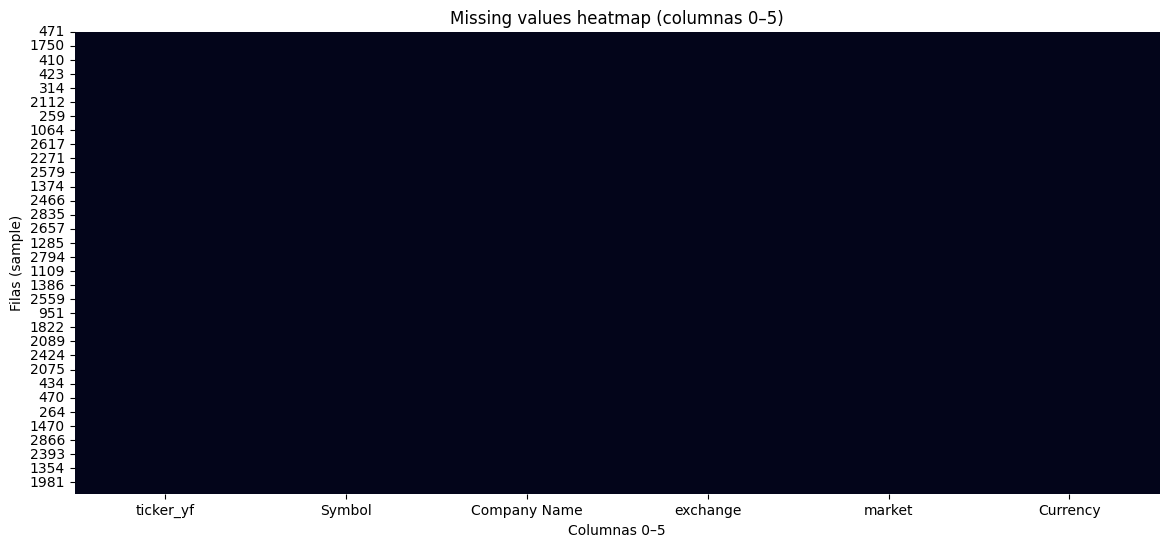

In [164]:
display(resumetable(df_nyse_final))
plot_missing_by_batches(df_nyse_final, sample_size=5000, cols_per_plot=40)

In [165]:
df_nyse_features, df_nyse_div_events = build_features_cached(
    companies=df_nyse_final.copy(),   # tu df de compañías NYSE
    cache_key="nyse",
    period="1y",
    stale_days=7
)

✅ Cache usado: nyse_features.csv + nyse_div_events.csv


In [166]:
cols_check = [
    "ticker_yf","Symbol","Company Name",
    "exchange","market","Currency",
    "last_close","dividend_ttm",
    "payments_ttm","div_freq","div_yield_ttm",
    "max_drawdown"
]

display(
    df_nyse_features[[c for c in cols_check if c in df_nyse_features.columns]]
    .sort_values("div_yield_ttm", ascending=False)
    .head(20)
)

df_nyse_features.shape


,ticker_yf,Symbol,Company Name,exchange,market,Currency,last_close,dividend_ttm,payments_ttm,div_freq,div_yield_ttm,max_drawdown
2353,SITC,SITC,SITE Centers Corp. Common Stock,NYSE,NYSE,USD,6.370000,6.750,4.0,Quarterly,1.059655,-0.593231
1757,MVO,MVO,MV Oil Trust Units of Beneficial Interests,NYSE,NYSE,USD,1.290000,0.905,4.0,Quarterly,0.701550,-0.883562
2487,SWZ,SWZ,Total Return Securities Fund Common Stock,NYSE,NYSE,USD,6.240000,3.292,3.0,Irregular,0.527564,-0.376333
100,AIV,AIV,Apartment Investment and Management Company Common Stock,NYSE,NYSE,USD,5.680000,2.830,2.0,Semi-Annual,0.498239,-0.422149
1316,HUYA,HUYA,"HUYA Inc. American depositary shares, each representing one Class A ordinary share",NYSE,NYSE,USD,3.120000,1.470,1.0,Annual,0.471154,-0.488987
37,AD,AD,"Array Digital Infrastructure, Inc. Common Shares",NYSE,NYSE,USD,49.009998,23.000,1.0,Annual,0.469292,-0.422802
350,BGSF,BGSF,"BGSF, Inc. Common Stock",NYSE,NYSE,USD,4.400000,2.000,1.0,Annual,0.454545,-0.587642
844,ECC,ECC,Eagle Point Credit Company Inc. Common Stock,NYSE,NYSE,USD,5.470000,1.680,12.0,Monthly,0.307130,-0.401532
1821,NLOP,NLOP,Net Lease Office Properties Common Shares of Beneficial Interest,NYSE,NYSE,USD,25.969999,7.200,2.0,Semi-Annual,0.277243,-0.262445
517,CCIF,CCIF,Carlyle Credit Income Fund Shares of Beneficial Interest,NYSE,NYSE,USD,4.680000,1.260,12.0,Monthly,0.269231,-0.429963


(2888, 23)

In [167]:
df_all = pd.concat(
    [df_features, df_lse_features, df_nyse_features],
    ignore_index=True
)

df_all.shape

(7780, 28)

In [168]:
pd.set_option("display.max_rows", 600)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.expand_frame_repr", False)

df_filtered = df_nyse_features[
    df_nyse_features["ticker_yf"].str.contains("AG|NNN|JEQP", case=False, na=False)
]

# display(df_filtered)

high_div = df_nyse_features[df_nyse_features["div_yield_ttm"].fillna(0) >= 0.09].copy()
high_div = high_div.sort_values("div_yield_ttm", ascending=False)
display(high_div)

,ticker_yf,Symbol,Company Name,exchange,market,Currency,last_close,max_drawdown,EMA_20,EMA_52,EMA_200,MACD,MACD_signal,RSI_14,dividend_ttm,payments_ttm,div_freq,last_div_date,div_yield_ttm,next_earnings_date,eps_estimate,reported_eps,surprise_pct
2353,SITC,SITC,SITE Centers Corp. Common Stock,NYSE,NYSE,USD,6.370000,-0.593231,7.211809,7.812343,10.279088,-0.181839,-0.184452,27.604170,6.750000,4.0,Quarterly,2025-12-15,1.059655,NaN,0.04,0.30,733.33
1757,MVO,MVO,MV Oil Trust Units of Beneficial Interests,NYSE,NYSE,USD,1.290000,-0.883562,1.716955,3.091988,5.081299,-0.656570,-0.808261,60.483868,0.905000,4.0,Quarterly,2025-10-15,0.701550,NaN,0.57,0.60,5.26
2487,SWZ,SWZ,Total Return Securities Fund Common Stock,NYSE,NYSE,USD,6.240000,-0.376333,6.093718,6.059491,6.509912,0.052601,0.033781,90.624939,3.292000,3.0,Irregular,2025-04-15,0.527564,NaN,NaN,NaN,NaN
100,AIV,AIV,Apartment Investment and Management Company Common Stock,NYSE,NYSE,USD,5.680000,-0.422149,5.666487,6.050709,7.308637,-0.051356,-0.095498,51.785713,2.830000,2.0,Semi-Annual,2025-10-16,0.498239,NaN,NaN,-0.01,NaN
1316,HUYA,HUYA,"HUYA Inc. American depositary shares, each representing one Class A ordinary share",NYSE,NYSE,USD,3.120000,-0.488987,2.971306,2.977467,3.202650,0.087741,0.041282,67.289712,1.470000,1.0,Annual,2025-07-01,0.471154,NaN,-0.21,0.02,109.64
37,AD,AD,"Array Digital Infrastructure, Inc. Common Shares",NYSE,NYSE,USD,49.009998,-0.422802,48.740111,49.562404,56.520496,0.441456,0.273250,67.236008,23.000000,1.0,Annual,2025-08-20,0.469292,NaN,NaN,NaN,NaN
350,BGSF,BGSF,"BGSF, Inc. Common Stock",NYSE,NYSE,USD,4.400000,-0.587642,4.305531,4.402802,4.949656,0.104028,0.100607,55.479465,2.000000,1.0,Annual,2025-10-01,0.454545,NaN,0.28,0.16,-41.82
844,ECC,ECC,Eagle Point Credit Company Inc. Common Stock,NYSE,NYSE,USD,5.470000,-0.401532,5.969460,6.180157,7.039092,-0.102550,-0.037392,33.561649,1.680000,12.0,Monthly,2025-12-11,0.307130,NaN,0.41,NaN,NaN
1821,NLOP,NLOP,Net Lease Office Properties Common Shares of Beneficial Interest,NYSE,NYSE,USD,25.969999,-0.262445,27.354690,28.516125,30.180303,-0.974427,-0.758625,31.636364,7.200000,2.0,Semi-Annual,2025-12-04,0.277243,NaN,NaN,NaN,NaN
517,CCIF,CCIF,Carlyle Credit Income Fund Shares of Beneficial Interest,NYSE,NYSE,USD,4.680000,-0.429963,5.024515,5.207243,6.012082,-0.103042,-0.060524,19.117655,1.260000,12.0,Monthly,2025-11-17,0.269231,NaN,NaN,NaN,NaN


In [169]:
def select_top_100(df_exchange):
    df = df_exchange.copy()

    # Convertir a numérico (CRÍTICO)
    df["max_drawdown"] = pd.to_numeric(df["max_drawdown"], errors="coerce")
    df["div_yield_ttm"] = pd.to_numeric(df["div_yield_ttm"], errors="coerce")
    df["RSI_14"] = pd.to_numeric(df["RSI_14"], errors="coerce")
    df["EMA_20"] = pd.to_numeric(df["EMA_20"], errors="coerce")
    df["EMA_52"] = pd.to_numeric(df["EMA_52"], errors="coerce")

    # quitar NaNs de columnas clave
    df = df.dropna(subset=["max_drawdown", "div_yield_ttm", "RSI_14", "EMA_20", "EMA_52"])

    # 1) Riesgo: NO perder más de 20%
    df = df[df["max_drawdown"] >= -0.20]

    # 2) Retorno: top percentil (ajústalo a 0.60 si quieres más estricto)
    yield_cut = df["div_yield_ttm"].quantile(0.50)
    df = df[df["div_yield_ttm"] >= yield_cut]

    # 3) Momentum
    df = df[(df["RSI_14"] > 40) & (df["EMA_20"] > df["EMA_52"])]

    # Score: mejor yield, mejor drawdown (más cerca a 0), mejor RSI
    df["score"] = (
        df["div_yield_ttm"].rank(ascending=False) +
        df["max_drawdown"].rank(ascending=False) +
        df["RSI_14"].rank(ascending=False)
    )

    out = df.sort_values("score").head(100)

    # ✅ validación final: esto debe ser VERDAD
    assert out["max_drawdown"].min() >= -0.20, f"Filtro roto: min DD = {out['max_drawdown'].min()}"
    return out




top_usa = select_top_100(df_nyse_features)
top_tsx = select_top_100(df_features)
top_lse = select_top_100(df_lse_features)

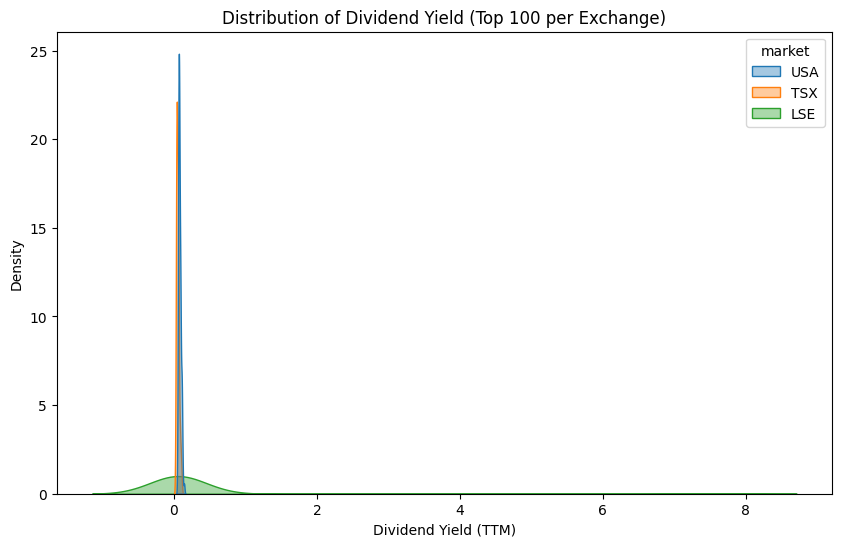

In [170]:
top_usa["market"] = "USA"
top_tsx["market"] = "TSX"
top_lse["market"] = "LSE"

df_all = pd.concat([top_usa, top_tsx, top_lse])

plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df_all,
    x="div_yield_ttm",
    hue="market",
    fill=True,
    common_norm=False,
    alpha=0.4
)

plt.title("Distribution of Dividend Yield (Top 100 per Exchange)")
plt.xlabel("Dividend Yield (TTM)")
plt.ylabel("Density")
plt.show()

Min DD por market:
market
LSE   -0.200000
TSX   -0.194631
USA   -0.196833
Name: max_drawdown, dtype: float64


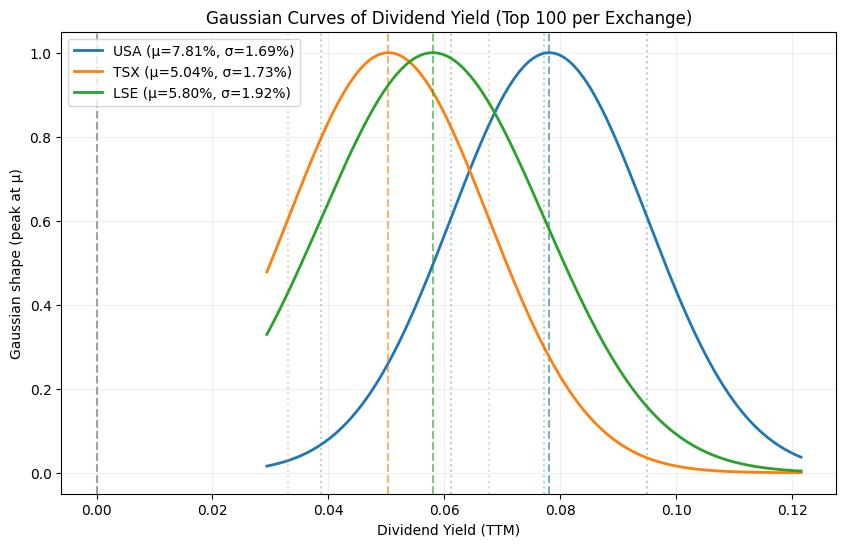

In [171]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_all_top = pd.concat([
    top_usa.assign(market="USA"),
    top_tsx.assign(market="TSX"),
    top_lse.assign(market="LSE"),
], ignore_index=True)

# sanity checks
print("Min DD por market:")
print(df_all_top.groupby("market")["max_drawdown"].min())

df_all_top["div_yield_ttm"] = pd.to_numeric(df_all_top["div_yield_ttm"], errors="coerce")
df_all_top = df_all_top.dropna(subset=["div_yield_ttm"])
df_all_top = df_all_top[df_all_top["div_yield_ttm"] > 0]

# recorta outliers extremos solo para que el eje no se destruya
hi = df_all_top["div_yield_ttm"].quantile(0.99)
df_all_top["yield"] = df_all_top["div_yield_ttm"].clip(0, hi)

markets = ["USA", "TSX", "LSE"]
colors = {"USA":"tab:blue", "TSX":"tab:orange", "LSE":"tab:green"}

x_min, x_max = df_all_top["yield"].min(), df_all_top["yield"].max()
x = np.linspace(x_min, x_max, 600)

plt.figure(figsize=(10,6))

for m in markets:
    vals = df_all_top.loc[df_all_top["market"] == m, "yield"].values
    mu = vals.mean()
    sigma = vals.std(ddof=0)
    if sigma == 0:
        continue

    # campana normal (no “density”, solo forma)
    y = np.exp(-0.5 * ((x - mu) / sigma) ** 2)

    plt.plot(x, y, color=colors[m], linewidth=2, label=f"{m} (μ={mu:.2%}, σ={sigma:.2%})")
    plt.axvline(mu, color=colors[m], linestyle="--", alpha=0.6)          # línea de la media
    plt.axvline(mu - sigma, color=colors[m], linestyle=":", alpha=0.35)  # -1σ
    plt.axvline(mu + sigma, color=colors[m], linestyle=":", alpha=0.35)  # +1σ

# referencia en 0% (si la quieres)
plt.axvline(0, color="black", linestyle="--", alpha=0.35)

plt.title("Gaussian Curves of Dividend Yield (Top 100 per Exchange)")
plt.xlabel("Dividend Yield (TTM)")
plt.ylabel("Gaussian shape (peak at μ)")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()


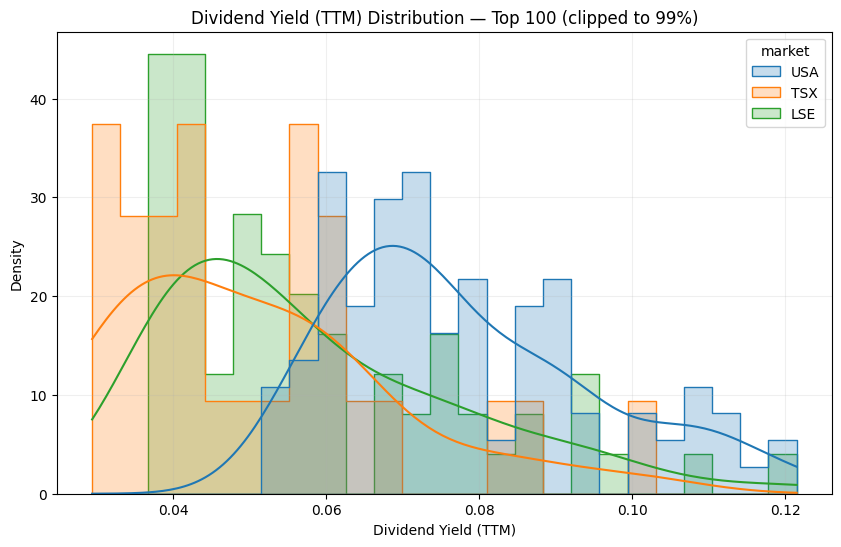

In [172]:
# recorta outliers para que no aplaste el gráfico
hi = df_all_top["div_yield_ttm"].quantile(0.99)
df_all_top["div_yield_clip"] = df_all_top["div_yield_ttm"].clip(0, hi)

plt.figure(figsize=(10,6))
sns.histplot(
    data=df_all_top,
    x="div_yield_clip",
    hue="market",
    stat="density",
    common_norm=False,
    bins=25,
    element="step",
    kde=True
)
plt.title("Dividend Yield (TTM) Distribution — Top 100 (clipped to 99%)")
plt.xlabel("Dividend Yield (TTM)")
plt.ylabel("Density")
plt.grid(True, alpha=0.2)
plt.show()


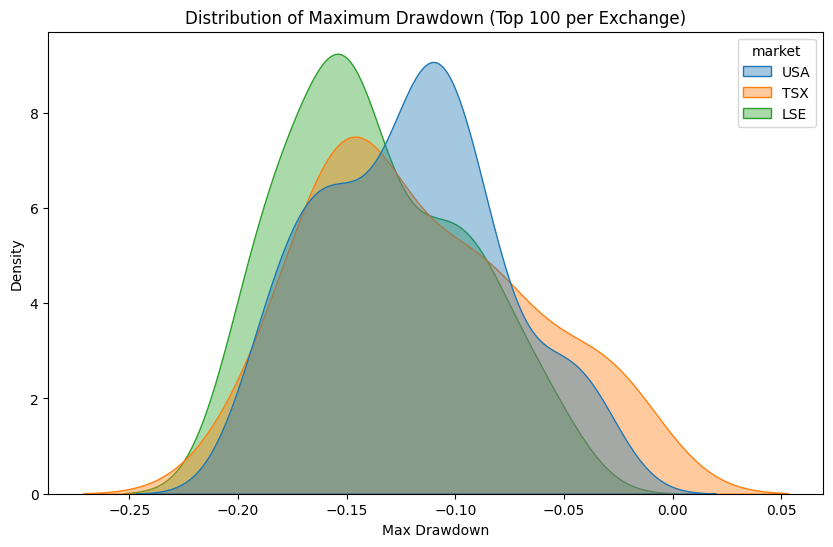

In [173]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df_all_top,
    x="max_drawdown",
    hue="market",
    fill=True,
    common_norm=False,
    alpha=0.4
)

plt.title("Distribution of Maximum Drawdown (Top 100 per Exchange)")
plt.xlabel("Max Drawdown")
plt.ylabel("Density")
plt.show()

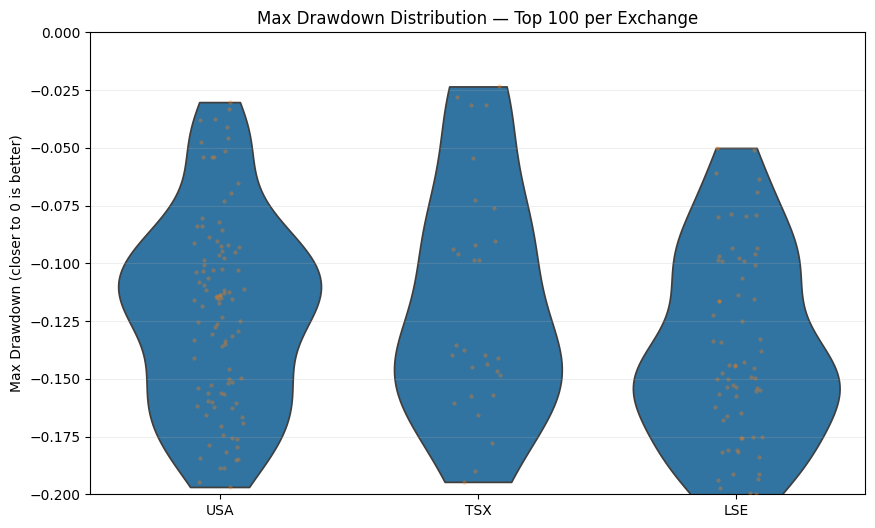

In [176]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.violinplot(data=df_all_top, x="market", y="max_drawdown", inner=None, cut=0)
sns.stripplot(data=df_all_top, x="market", y="max_drawdown", size=3, alpha=0.35)

plt.title("Max Drawdown Distribution — Top 100 per Exchange")
plt.xlabel("")
plt.ylabel("Max Drawdown (closer to 0 is better)")
plt.ylim(-0.20, 0)
plt.grid(True, axis="y", alpha=0.2)
plt.show()


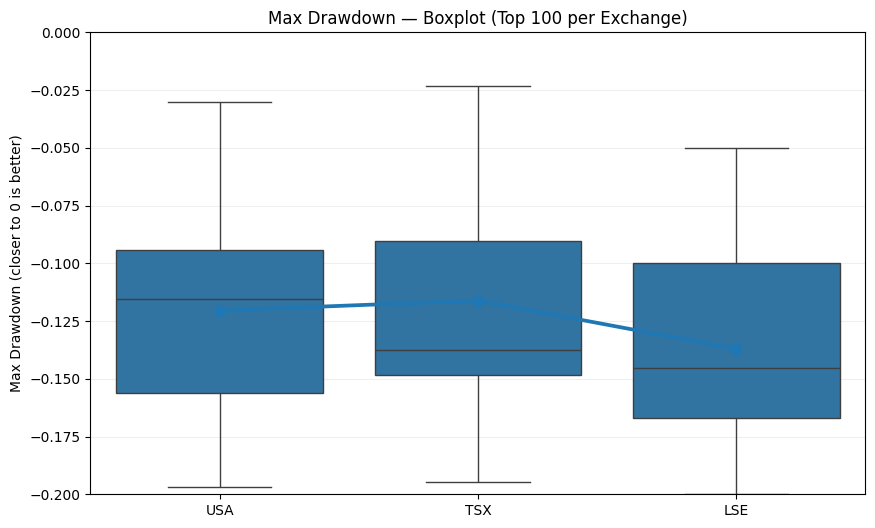

In [175]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(data=df_all_top, x="market", y="max_drawdown", showfliers=False)
sns.pointplot(data=df_all_top, x="market", y="max_drawdown", estimator="mean", errorbar=None)

plt.title("Max Drawdown — Boxplot (Top 100 per Exchange)")
plt.xlabel("")
plt.ylabel("Max Drawdown (closer to 0 is better)")
plt.ylim(-0.20, 0)
plt.grid(True, axis="y", alpha=0.2)
plt.show()
